<a href="https://colab.research.google.com/github/praveendhac/aiml-iisc-assignments/blob/main/assignment6/120261627_quiz6_cnn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Convolutional Neural Networks
- https://www.youtube.com/watch?v=FE5iBi1cakg
- https://www.youtube.com/watch?v=zfiSAzpy9NM


In [2]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import f1_score

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.callbacks import CSVLogger
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
from tensorflow.keras import layers, models

import pandas as pd

import random



In [ ]:
# Google Colab does not support direct folder uploads
!pwd
!ls -lsh /content
!file /content/Cats_Dogs_dataset.zip
!unzip Cats_Dogs_dataset.zip



Streaming output truncated to the last 5000 lines.
  inflating: Cats_Dogs_dataset/Dataset (4000 each)/cats/cat.3347.jpg  
  inflating: __MACOSX/Cats_Dogs_dataset/Dataset (4000 each)/cats/._cat.3347.jpg  
  inflating: Cats_Dogs_dataset/Dataset (4000 each)/cats/cat.975.jpg  
  inflating: __MACOSX/Cats_Dogs_dataset/Dataset (4000 each)/cats/._cat.975.jpg  
  inflating: Cats_Dogs_dataset/Dataset (4000 each)/cats/cat.2059.jpg  
  inflating: __MACOSX/Cats_Dogs_dataset/Dataset (4000 each)/cats/._cat.2059.jpg  
  inflating: Cats_Dogs_dataset/Dataset (4000 each)/cats/cat.1550.jpg  
  inflating: __MACOSX/Cats_Dogs_dataset/Dataset (4000 each)/cats/._cat.1550.jpg  
  inflating: Cats_Dogs_dataset/Dataset (4000 each)/cats/cat.746.jpg  
  inflating: __MACOSX/Cats_Dogs_dataset/Dataset (4000 each)/cats/._cat.746.jpg  
  inflating: Cats_Dogs_dataset/Dataset (4000 each)/cats/cat.9.jpg  
  inflating: __MACOSX/Cats_Dogs_dataset/Dataset (4000 each)/cats/._cat.9.jpg  
  inflating: Cats_Dogs_dataset/Dataset (4

In [ ]:


# Paths to your two directories
dir1 = "Cats_Dogs_dataset/Dataset (1000 each)"
dir2 = "Cats_Dogs_dataset/Dataset (4000 each)"

# Load datasets separately
ds1 = tf.keras.utils.image_dataset_from_directory(
    dir1,
    image_size=(224, 224),
    batch_size=32,
    shuffle=True,
    seed=42
)

ds2 = tf.keras.utils.image_dataset_from_directory(
    dir2,
    image_size=(224, 224),
    batch_size=32,
    shuffle=True,
    seed=42
)

# Combine both datasets
full_dataset = ds1.concatenate(ds2)

# Get dataset size
dataset_size = full_dataset.cardinality().numpy()
print(f"dataset_size: {dataset_size}")

train_size = int(0.8 * dataset_size)

# Split dataset
train_ds = full_dataset.take(train_size)
val_ds = full_dataset.skip(train_size)

dataset_size = full_dataset.cardinality().numpy()

# Compute split sizes
train_size = int(0.8 * dataset_size)

# Split dataset
train_data = full_dataset.take(train_size)
other_data = full_dataset.skip(train_size)

print("Train batches:", train_data.cardinality().numpy())
print("Other batches (will be further split into validation & test data):", other_data.cardinality().numpy())

# Split remaining 20% into 10% val + 10% test
other_size = other_data.cardinality().numpy()
val_size = other_size // 2

val_data = other_data.take(val_size)
test_data = other_data.skip(val_size)

print("Validation batches:", val_data.cardinality().numpy())
print("Test batches:", test_data.cardinality().numpy())




Found 2000 files belonging to 2 classes.
Found 8000 files belonging to 2 classes.
dataset_size: 313
Train batches: 250
Other batches (will be further split into validation & test data): 63
Validation batches: 31
Test batches: 32


In [ ]:
# optimize pipeline

AUTOTUNE = tf.data.AUTOTUNE

train_data = train_data.cache().prefetch(buffer_size=AUTOTUNE)
val_data = val_data.cache().prefetch(buffer_size=AUTOTUNE)
test_data = test_data.cache().prefetch(buffer_size=AUTOTUNE)

# Data Augmentation
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1),
])

In [ ]:
#build CNN model

num_classes = len(ds1.class_names)

model = models.Sequential([

    # ✅ Proper input layer
    layers.Input(shape=(224, 224, 3)),

    layers.Rescaling(1./255),

    data_augmentation,

    layers.Conv2D(32, (3,3), activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D(),

    layers.Flatten(),

    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),

    layers.Dense(num_classes, activation='softmax') #can be "sigmoid" too
])

In [56]:
# build confusion matrix
# Collect true labels and predictions
y_true = []
y_pred = []

for images, labels in test_data:
    preds = model.predict(images)
    preds = np.argmax(preds, axis=1)

    y_true.extend(labels.numpy())
    y_pred.extend(preds)

# Convert to numpy arrays
#y_true = np.array(y_true)
#y_pred = np.array(y_pred)

# Compute confusion matrix
#cm = confusion_matrix(y_true, y_pred)

#print("Confusion Matrix:\n", cm)


# Assuming you already have:
# y_true and y_pred from your model

# Example (REMOVE if already defined)
# y_true = np.array([...])
# y_pred = np.array([...])

# Compute confusion matrix manually (binary: Cat=0, Dog=1)
cm = np.zeros((2, 2), dtype=int)

for t, p in zip(y_true, y_pred):
    cm[t][p] += 1

# Extract values
TN = cm[0][0]  # Actual Cat, Predicted Cat
FP = cm[0][1]  # Actual Cat, Predicted Dog
FN = cm[1][0]  # Actual Dog, Predicted Cat
TP = cm[1][1]  # Actual Dog, Predicted Dog

# Compute F1 score (for Dog class = 1)
f1 = f1_score(y_true, y_pred)

# Create DataFrame with exact format
df_cm = pd.DataFrame({
    "Predicted_Cat": [TN, FN],
    "Predicted_Dog": [FP, TP],
    "F1 Score": ["", f1]   # F1 only in second row
}, index=["Actual_Cat", "Actual_Dog"])

# Save to CSV
df_cm.to_csv("120261627_confusion_matrix.csv")

# Compute confusion matrix
cm = confusion_matrix(y_true, y_pred)

print("Confusion Matrix (CSV):\n", cm)

print(df_cm)

1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 928ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 927ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step   
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 915ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 939ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 941ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 911ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 910ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 953ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 830ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 915ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 928ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 930ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 960ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 898ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 935ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 903ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 905ms/step
1/1 ━━━━━━

class_names = ['cats', 'dogs']


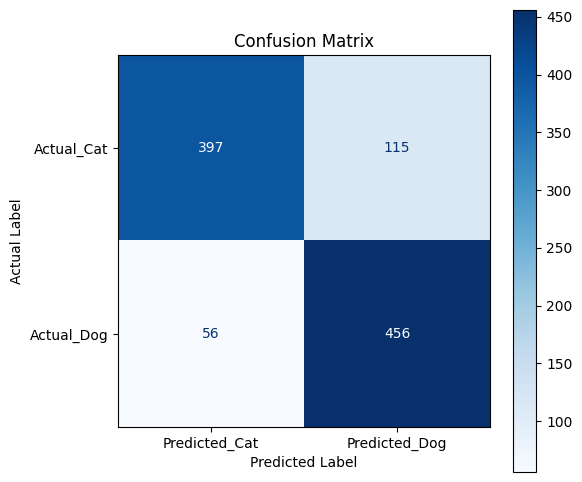

<Figure size 600x600 with 0 Axes>

In [60]:
# visualize confusion matrix
class_names = ds1.class_names
print(f"class_names = {class_names}")


# Create plot
fig, ax = plt.subplots(figsize=(6,6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)


disp.plot(cmap='Blues', values_format='d', ax=ax)

# Set custom axis labels (IMPORTANT)
ax.set_xlabel("Predicted Label")
ax.set_ylabel("Actual Label")

# Rename tick labels to required format
ax.set_xticklabels(["Predicted_Cat", "Predicted_Dog"])
ax.set_yticklabels(["Actual_Cat", "Actual_Dog"])

plt.title("Confusion Matrix (JPG)")

plt.figure(figsize=(6,6))

# Save confusion matrix as JPG
plt.savefig("120261627_confusion_largesplit.jpg", dpi=300, bbox_inches='tight')

plt.show()

In [ ]:
# compile our CNN model
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_1 (Rescaling)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,218 (42.61 MB)

 Trainable params: 11,169,218 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# train model

# Create CSV logger
csv_logger = CSVLogger("120261627_largesplit.csv", append=False)

history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=10,
    callbacks=[csv_logger]
)

Epoch 1/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 985s 4s/step - accuracy: 0.7986 - loss: 0.4398 - val_accuracy: 0.8276 - val_loss: 0.3987
Epoch 2/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 978s 4s/step - accuracy: 0.8057 - loss: 0.4270 - val_accuracy: 0.8155 - val_loss: 0.4032
Epoch 3/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 973s 4s/step - accuracy: 0.8139 - loss: 0.4063 - val_accuracy: 0.8216 - val_loss: 0.4231
Epoch 4/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 973s 4s/step - accuracy: 0.8109 - loss: 0.4087 - val_accuracy: 0.8175 - val_loss: 0.4070
Epoch 5/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 973s 4s/step - accuracy: 0.8243 - loss: 0.3888 - val_accuracy: 0.8175 - val_loss: 0.4036
Epoch 6/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 980s 4s/step - accuracy: 0.8300 - loss: 0.3818 - val_accuracy: 0.8216 - val_loss: 0.3868
Epoch 7/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 975s 4s/step - accuracy: 0.8329 - loss: 0.3720 - val_accuracy: 0.8387 - val_loss: 0.3790
Epoch 8/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 964s 4s/step - accuracy: 0.8404 - loss: 0.3585 - val_accu

In [ ]:
# evaluate model

test_loss, test_acc = model.evaluate(test_data)

print("Test Accuracy:", test_acc)

32/32 ━━━━━━━━━━━━━━━━━━━━ 47s 993ms/step - accuracy: 0.8330 - loss: 0.3560
Test Accuracy: 0.8330078125


In [ ]:
#save model
model.save("cnn_model_iisc_q6_pd.keras")

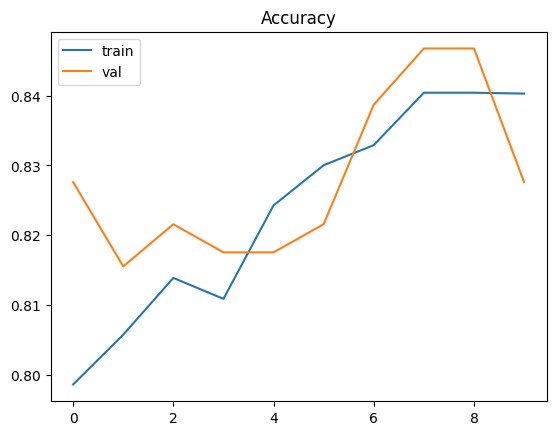

In [ ]:
# plot training surves

plt.plot(history.history['accuracy'], label='train')
plt.plot(history.history['val_accuracy'], label='val')
plt.legend()
plt.title("Accuracy")
plt.show()

#

# CNN Model using 50–25–25 Data Split (Small Split)

In [62]:
print(f"dataset_size (small): {dataset_size}")
train_size_small = int(0.5 * dataset_size)

# Split dataset
train_ds_small = full_dataset.take(train_size_small)
val_ds_small = full_dataset.skip(train_size_small)

dataset_size_small = full_dataset.cardinality().numpy()

# Compute split sizes
train_size_small = int(0.5 * dataset_size_small)

# Split dataset
train_data_small = full_dataset.take(train_size_small)
other_data_small = full_dataset.skip(train_size_small)

print("Train batches:", train_data_small.cardinality().numpy())
print("Other batches (will be further split into validation & test data):", other_data_small.cardinality().numpy())

# Split remaining 20% into 10% val + 10% test
other_size_small = other_data_small.cardinality().numpy()
val_size_small = other_size_small // 2

val_data_small = other_data_small.take(val_size_small)
test_data_small = other_data_small.skip(val_size_small)

print("Validation batches:", val_data_small.cardinality().numpy())
print("Test batches:", test_data_small.cardinality().numpy())

dataset_size (small): 313
Train batches: 156
Other batches (will be further split into validation & test data): 157
Validation batches: 78
Test batches: 79


In [1]:
# optimize pipeline

AUTOTUNE = tf.data.AUTOTUNE

train_data_small = train_data_small.cache().prefetch(buffer_size=AUTOTUNE)
val_data_small = val_data_small.cache().prefetch(buffer_size=AUTOTUNE)
test_data_small = test_data_small.cache().prefetch(buffer_size=AUTOTUNE)

# Data Augmentation
data_augmentation_small = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1),
])

#build CNN model

num_classes = len(ds1.class_names)

model = models.Sequential([

    # ✅ Proper input layer
    layers.Input(shape=(224, 224, 3)),

    layers.Rescaling(1./255),

    data_augmentation_small,

    layers.Conv2D(32, (3,3), activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D(),

    layers.Flatten(),

    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),

    layers.Dense(num_classes, activation='softmax') #can be "sigmoid" too
])

# build confusion matrix
# Collect true labels and predictions
y_true = []
y_pred = []

for images, labels in test_data_small:
    preds = model.predict(images)
    preds = np.argmax(preds, axis=1)

    y_true.extend(labels.numpy())
    y_pred.extend(preds)


# Compute confusion matrix manually (binary: Cat=0, Dog=1)
cm_man_small = np.zeros((2, 2), dtype=int)

for t, p in zip(y_true, y_pred):
    cm[t][p] += 1

# Extract values
TN = cm_man_small[0][0]  # Actual Cat, Predicted Cat
FP = cm_man_small[0][1]  # Actual Cat, Predicted Dog
FN = cm_man_small[1][0]  # Actual Dog, Predicted Cat
TP = cm_man_small[1][1]  # Actual Dog, Predicted Dog

# Compute F1 score (for Dog class = 1)
f1 = f1_score(y_true, y_pred)

# Create DataFrame with exact format
df_cm = pd.DataFrame({
    "Predicted_Cat": [TN, FN],
    "Predicted_Dog": [FP, TP],
    "F1 Score": ["", f1]   # F1 only in second row
}, index=["Actual_Cat", "Actual_Dog"])

# Save to CSV
df_cm.to_csv("120261627_confusion_smallsplit.csv")

# Compute confusion matrix
cm = confusion_matrix(y_true, y_pred)

print("Confusion Matrix (CSV):\n", cm)

print(df_cm)


# visualize confusion matrix
class_names = ds1.class_names
print(f"class_names = {class_names}")


# Create plot
fig, ax = plt.subplots(figsize=(6,6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)


disp.plot(cmap='Blues', values_format='d', ax=ax)

# Set custom axis labels (IMPORTANT)
ax.set_xlabel("Predicted Label")
ax.set_ylabel("Actual Label")

# Rename tick labels to required format
ax.set_xticklabels(["Predicted_Cat", "Predicted_Dog"])
ax.set_yticklabels(["Actual_Cat", "Actual_Dog"])

plt.title("Confusion Matrix (JPG)")

plt.figure(figsize=(6,6))

# Save confusion matrix as JPG
plt.savefig("120261627_confusion_smallsplit.jpg", dpi=300, bbox_inches='tight')

plt.show()

NameError: name 'tf' is not defined

In [ ]:
# compile our CNN model
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

In [ ]:
# train model

# Create CSV logger
csv_logger = CSVLogger("120261627_largesplit.csv", append=False)

history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=10,
    callbacks=[csv_logger]
)

# evaluate model

test_loss, test_acc = model.evaluate(test_data)

print("Test Accuracy:", test_acc)

#save model
model.save("cnn_model_iisc_q6_pd_small.keras")

# plot training surves

plt.plot(history.history['accuracy'], label='train')
plt.plot(history.history['val_accuracy'], label='val')
plt.legend()
plt.title("Accuracy")
plt.show()